# Tree-based model for creating weights from spatial data

We use the exact coordinates of the listings to train a tree-based model that creates a price map of the city. For each Airbnb the model outputs an embedded categorial variable that can be used as an input for neural learning. Precisely our approach features a histogram gradient boosting regressor that is trained on joined inputs of one-hot encoded neighbourhoods and coordinates.

In [1]:
# Imports:

import import_ipynb
import numpy as np
import pandas as pd
import geopandas as gpd
import sklearn
import matplotlib.pyplot as plt

from general import *
from sklearn.preprocessing import RobustScaler

## Preprocessing spatial data

For later sanity checks we will use the actual neighbourhood's influence. Also, we prepare the data for later visualization.

In [2]:
# Import data:
listings_df = load_listings()
neighbourhoods_df = pd.read_csv("data/neighbourhoods.csv")
neighbourhoods_gdf = gpd.read_file("data/neighbourhoods.geojson")

# Removing outliers:
listings_df.drop(listings_df[listings_df["price"] > 1000].index, inplace=True)

# One-hot encoding neighbourhoods:
n = len(neighbourhoods_df)
nbh_encoding = dict()
for i, nbh in enumerate(neighbourhoods_df["neighbourhood"]):
    nbh_encoding[nbh] = np.eye(n, dtype=int)[i]
listings_df["nbh_one_hot"] = listings_df["neighbourhood_cleansed"].map(nbh_encoding)

# Adding geometry and rounding coordinates afterwards:
positions = gpd.points_from_xy(listings_df.longitude, listings_df.latitude)
listings_gdf = gpd.GeoDataFrame(listings_df, geometry=positions)
listings_gdf["longitude"], listings_df["latitude"] = listings_df["longitude"].round(5), listings_df["latitude"].round(5)
# We choose to keep original positions for later visualization to make sure listings of appartments on different floors of the same building are not merged into one point. However, the raw data's precision of assumingly at least 10 centimeters (according to six decimal digits in coordinate values as Naples lies far from the Equator) is unecessary for model training. We therefore (conservatively) round to sub-meter accuracy.

In [3]:
def extract_X_y(gdf):
    X_nbh = np.vstack(gdf["nbh_one_hot"].to_numpy())
    X_coo = gdf[["latitude", "longitude"]].to_numpy()
    y = gdf["price"].to_numpy()
    return X_nbh, X_coo, y

In [4]:
# Prepare data:
train_gdf, test_gdf = sklearn.model_selection.train_test_split(listings_gdf, test_size=0.2, random_state=0)
X_nbh_train, X_coo_train, y_train = extract_X_y(train_gdf)
X_nbh_test, X_coo_test, y_test = extract_X_y(test_gdf)

## Growing the tree

In [5]:
def grow_tree(X_train, y_train):
    model = sklearn.tree.DecisionTreeRegressor(max_leaf_nodes=30, min_samples_leaf=150, random_state=0)
    return model.fit(X_train, y_train)

In [6]:
coo_tree = grow_tree(X_coo_train, y_train)
y_pred = coo_tree.predict(X_coo_test)
validate(X_coo_test, y_test, y_pred)

RMSE: 78.92376330143261 (std: 81.81293365053153)
MAE: 46.25371010782974
R2: 0.06938159139299482


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
from sklearn.tree import _tree
def get_leaf_rectangles(tree_model, X):
    """X is numpy array with columns [lat, lon]"""
    tree_ = tree_model.tree_

    lat_min_global, lat_max_global = X[:, 0].min(), X[:, 0].max()
    lon_min_global, lon_max_global = X[:, 1].min(), X[:, 1].max()

    leaf_boxes = []

    def recurse(node, lat_min, lat_max, lon_min, lon_max):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            leaf_boxes.append({
                'geometry': box(lon_min, lat_min, lon_max, lat_max),
                'predicted': tree_.value[node][0][0],
                'n_samples': tree_.n_node_samples[node],
                'leaf_id': node
            })
        else:
            feature_idx = tree_.feature[node]
            threshold = tree_.threshold[node]
            if feature_idx == 0:  # lat
                recurse(tree_.children_left[node],  lat_min, threshold, lon_min, lon_max)
                recurse(tree_.children_right[node], threshold, lat_max, lon_min, lon_max)
            else:  # lon
                recurse(tree_.children_left[node],  lat_min, lat_max, lon_min, threshold)
                recurse(tree_.children_right[node], lat_min, lat_max, threshold, lon_max)

    recurse(0, lat_min_global, lat_max_global, lon_min_global, lon_max_global)
    return gpd.GeoDataFrame(leaf_boxes, crs='EPSG:4326')

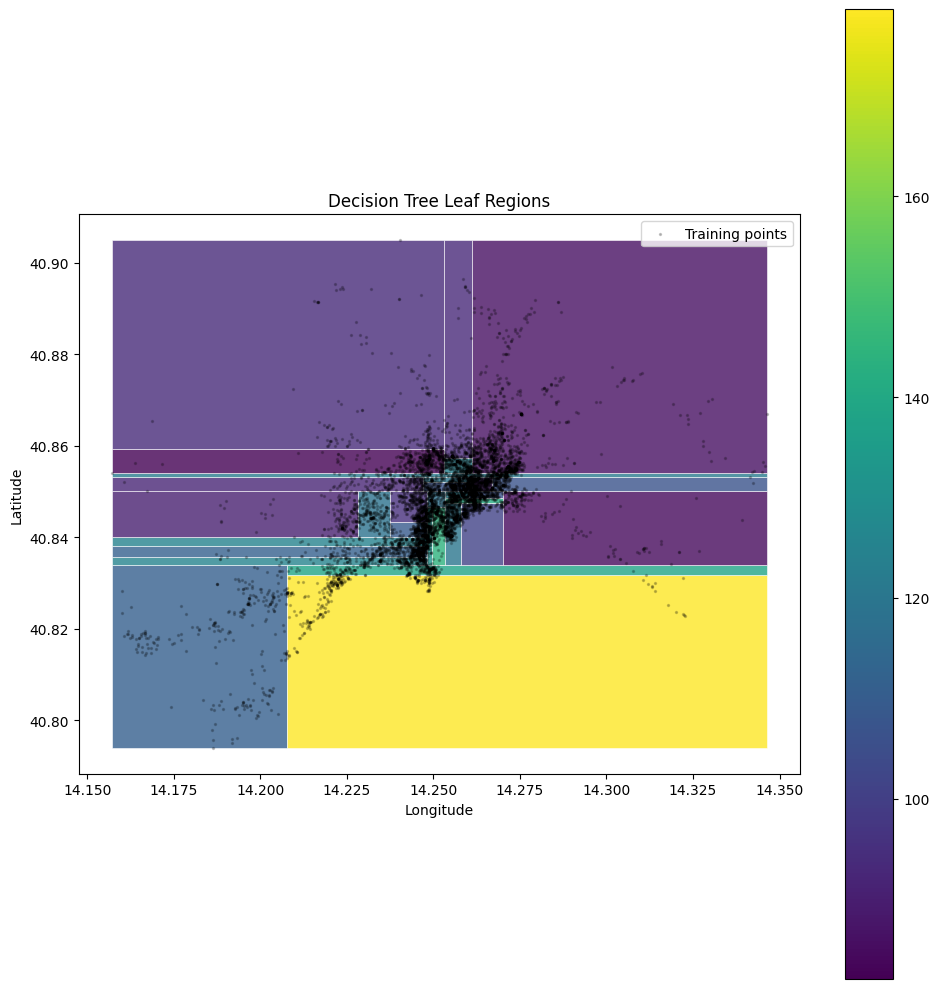

In [14]:
leaf_gdf = get_leaf_rectangles(coo_tree, X_coo_train)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
leaf_gdf.plot(column='predicted', cmap='viridis',
              edgecolor='white', linewidth=0.5,
              legend=True, alpha=0.8, ax=ax)

# Overlay actual data points
ax.scatter(train_gdf["longitude"], train_gdf["latitude"], c='black', s=2, alpha=0.2, label='Training points')

plt.title('Decision Tree Leaf Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()